# skills 
1. React 
2. Toool_calls
3. AWS

ENV : langchain-core, langchain-openai, langchian-google-genai

In [39]:
import os
from dotenv import load_dotenv
load_dotenv()

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")



In [40]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm_client = ChatGoogleGenerativeAI(api_key=GEMINI_API_KEY, model="gemini-3.6-flash", temperature=0.0)

In [41]:
# Structure your message
messages = [
    ("system", "You are a helpful assistant that summarizes complex ideas simply."),
    ("human", "Explain quantum computing in one sentence.")
]

# Make the call
response = llm_client.invoke(messages)

# Print the text response
print(response.content)

c:\Users\tella\OneDrive\Desktop\InterviewKickStart\py-frameworks\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': 'Quantum computing uses the strange rules of physics to process information in multiple states at once, allowing it to solve complex problems far faster than traditional computers.', 'extras': {'signature': 'EosRCogRAWkUfRNid5AG9nkq8ICkmC4rf4GD3uDNj/UB5fwsSZ/+DORcgFUqOo0kJ27jeKYsSj6t2MFuGQIJsNFPoVaC2Au9gLu+l13dFYCguAQgpHM00XhLaerRLmHacnqf97xZmTRu1xiiN/MoymSEy/VJP7J/6nZcubgs43YpLNx1zFXZ7iQjeAHsK+i5chsmjJLA5XoHxRZ3zXzqnQBgHw15KEAGlZtC5BFE5JaVOVzrGdOaI6IJBg2BNjI8miFn72VTiZVmhIvbCY1KV8H2nHrTjhj7eYOnKRmIpRsuyRDXd3/cw/G5XeOPlDVjci/hE1j4IUMaGezaapVUByHgn2gQYB1YCZFzvLnn51IQUP3HGLheOVovM5s0zQ3eOnwvkEiuTXwmNeophDYuKObmSGWhKeT5oNn9Q6s32UtNvbqbxrW0sM2mKWtgfEXiaY6wl7eYKar6h2dwpdh5rPN3CrEU8KiI3F7e23wct+z/tZbD5q6HpTl8zGComL/VUdpnkDC8YCDzfE34av0OXfh3XtNT8PRLvpe4Ldg0A9B/ZUNAh52V2OsZKiKpGzY310ZLpHWVCnyHn7mg8F1jW4QtWYeIRnN04BmsOl+ibEKJwu4+acjJpowk0ezqX+I2wdy4F/hlZB5RD6I2tPvvmHDSyZIMLomtVmOvg9jvppfH37DxZ/4ubDKQ+4X+FN15VpM+qr5B/Xp+B1IDWrQiEe3kd7JjqgMXnTvASIM5CPE70QYmC+5VFIOxQXN8le

In [42]:
print(response.text)

Quantum computing uses the strange rules of physics to process information in multiple states at once, allowing it to solve complex problems far faster than traditional computers.


# React 

# Find the capital of country , Then find the population of the capital (tool_call)

Action
- Call the search Tool

Action Input :
- {"query": capital of xxxxx}

observe:
- xxxx is teh capital of xxxxxx

reasoning:
- i have capital of xxxxxx
- but i want latest population of xxxxx
- i want to use search tool

Action:
- I will call search tool

Action input:
-{ "query" : "population of xxxx"}

Obseravtion:
- XXXX amount of population in xxxx

Reasoning
- Now, i have population and capital of xxx and its enough for me to answer query

Action:
 Final out =" population of xxxxx capital if xxxxx is xxxxx" 



In [43]:
from langchain_groq import ChatGroq
from groq import Groq
#client = Groq(api_key=os.getenv("GROQ_API_KEY"))
llm_groq = ChatGroq(model="allam-2-7b", api_key=os.getenv("GROQ_API_KEY"))
#print([model.id for model in client.models.list().data])

In [44]:
from langchain.agents import create_agent

In [45]:
my_agent = create_agent(
    model=llm_groq,
    tools=[]
)

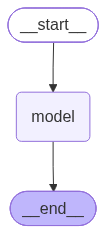

In [46]:
my_agent


In [47]:
my_agent.invoke({"messages": [{"role": "user", "content": "Hello!"}]})

{'messages': [HumanMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='68eb8755-a5e7-418f-9f54-27c1894fdf6f'),
  AIMessage(content="Hello! How can I assist you today? If you have questions or need information on a topic, feel free to ask. \n\nIf you're looking for advice or help with a problem, please provide me with some context so I can provide a more tailored response. Don't hesitate to let me know how I can be of help. ", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 9, 'total_tokens': 84, 'completion_time': 0.053800966, 'completion_tokens_details': None, 'prompt_time': 0.000914186, 'prompt_tokens_details': None, 'queue_time': 0.197439534, 'total_time': 0.054715152}, 'model_name': 'allam-2-7b', 'system_fingerprint': 'fp_ff744b2c7a', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0dade-8361-7182-a177-7fcca66ccb59-0', tool_calls=[], invalid_too

In [48]:
from langchain.tools import tool
from langchain_community.tools import Tool

@tool
def my_tool_function(inputText : str) ->str :
    """  sample tool call string processing the input textually
      Arguments:
          inputText (str): The input text to be processed.
      Returns:
          str: The processed input text.
    """
    return f"Processed input: {inputText}"


In [49]:
tools= [my_tool_function]

In [50]:
from langchain.agents import create_agent

In [67]:
llm_groq = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0,
)

In [68]:
agent_with_dummytool= create_agent(model=llm_groq, tools=tools)

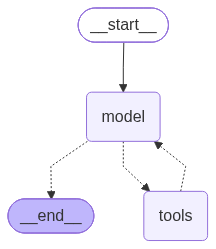

In [69]:
agent_with_dummytool

In [71]:
agent_with_dummytool.invoke({
    "messages": [
        ("user", "Process this input text: 'hello' before that convert it to uppercase and use tool call")
    ]
})

{'messages': [HumanMessage(content="Process this input text: 'hello' before that convert it to uppercase and use tool call", additional_kwargs={}, response_metadata={}, id='ed4931a9-757d-4361-8a99-0e963ca8d6ec'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "The user wants to process input text 'hello' before that convert it to uppercase and use tool call. So we need to first convert to uppercase: 'HELLO'. Then call the tool my_tool_function with inputText: 'HELLO'. The tool returns processed text (maybe same). We'll call it.", 'tool_calls': [{'id': 'fc_1bb5b470-1cf2-46ab-9d5e-25a45a465017', 'function': {'arguments': '{"inputText":"HELLO"}', 'name': 'my_tool_function'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 169, 'total_tokens': 262, 'completion_time': 0.193488561, 'completion_tokens_details': {'reasoning_tokens': 63}, 'prompt_time': 0.006434958, 'prompt_tokens_details': None, 'queue_time': 0.115147102, 'to

In [ ]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.agents import create_agent
from langchain.tools import tool

load_dotenv()

if not os.getenv("GROQ_API_KEY"):
    raise ValueError("GROQ_API_KEY is missing from .env")

llm_groq = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=os.environ["GROQ_API_KEY"],
    temperature=0,
)

@tool(name="my_tool_function", description="Processes input text.")
def my_tool_function(input_text: str) -> str:
    """Processes input text."""
    return f"Processed input: {input_text}"

agent_with_dummytool = create_agent(
    model=llm_groq,
    tools=[my_tool_function],
)

result = agent_with_dummytool.invoke({
    "messages": [
        ("user", "Process this input text: 'hello' before that convert it to uppercase and use tool call")
    ]
})

print(result["messages"][-1].content)

The processed result is:

**Processed input: HELLO**
